In [2]:
print("""This script was written in support of the experiments carried out in:
Nic Ezzell, Lev Barash, Itay Hen, A universal black-box quantum Monte Carlo approach to quantum phase transitions, arXiv:2408.03924v2 (2025).""")

This script was written in support of the experiments carried out in:
Nic Ezzell, Lev Barash, Itay Hen, A universal black-box quantum Monte Carlo approach to quantum phase transitions, arXiv:2408.03924v2 (2025).


In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import pandas as pd
import sys

new_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r"\usepackage{amsmath}\usepackage{amsfonts}")

In [4]:
ddir = "../data/zhang_prl_rot_model_fidsus_curve_sign_check_data_2024-05-20_15-29-46.csv"
cols = ["n", "lam", "beta", "H1", "H1_std", "int1", "int1_std", "int2", "int2_std", "int3", "int3_std", "rng", "eps", "l", "Tsteps", "steps", "stepsPerMeasurement", "sign", "sign_std", "q", "qmax", "time"]
df = pd.read_csv(ddir, names=cols, skiprows=1)
# add fid sus column
df['fidsus'] = df.int3 - (df.beta*df.H1)**2/8
exact = np.array([-0.7099133855459768, 6.609155439246638, 16.522888597795358, 4.053481186458256, 2.478553014654032])

In [5]:
df100 = df[df.n == 100]
df2 = df[df.n == 2]

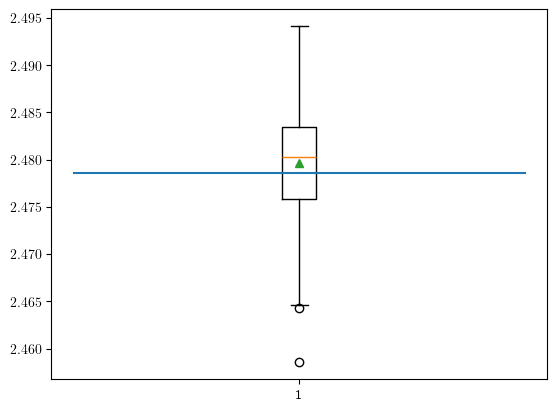

In [6]:
plt.boxplot(df2.fidsus, showmeans=True)
plt.plot([0, 1, 2], [exact[-1] for _ in range(3)])

## Pick out those instances that agree with each observable

In [7]:
h1_cond = np.abs(df100.H1 - exact[0]) < 2 * df100.H1_std
int1_cond = np.abs(df100.int1 - exact[1]) < 2 * df100.int1_std
int2_cond = np.abs(df100.int2 - exact[2]) < 2 * df100.int2_std
int3_cond = np.abs(df100.int3 - exact[3]) < 2 * df100.int3_std

fidsus_pdiff = (np.abs(df100.fidsus - exact[4]) / exact[4]) * 100
df100["fidsus_pdiff"] = fidsus_pdiff
close_cond = (np.abs(df100.fidsus - exact[4]) / exact[4]) * 100 < 5
df100["close"] = close_cond

/var/folders/2w/_70fq7w11c36fkhz8pnqp8gw0000gp/T/ipykernel_22384/121899426.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df100["fidsus_pdiff"] = fidsus_pdiff
/var/folders/2w/_70fq7w11c36fkhz8pnqp8gw0000gp/T/ipykernel_22384/121899426.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df100["close"] = close_cond


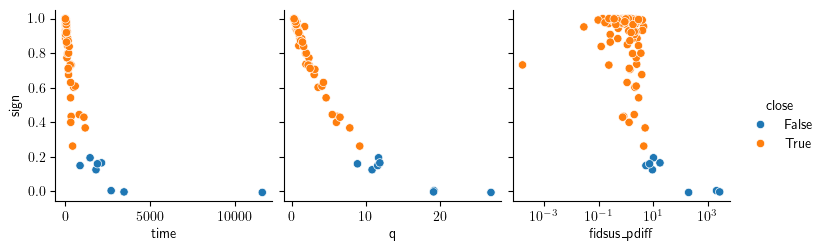

In [8]:
g = sns.pairplot(df100, y_vars="sign", x_vars=["time", "q", "fidsus_pdiff"], hue="close")
#g.fig.suptitle(r"Random 100q rotations of PRL model with $\beta = 5.0, \lambda = 1.0$", y=1.08)
plt.xscale("log")
#plt.savefig("figures/prl_rot_close_check_plot.pdf", bbox_inches="tight")

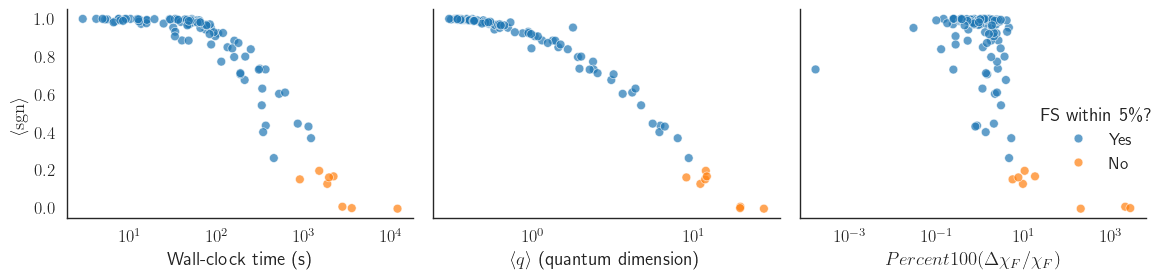

In [9]:
sns.set_context("paper", font_scale=1.4)
sns.set_style("white")

label_map = {
    "time": "Wall-clock time (s)",
    "q": r"$\langle q \rangle$ (quantum dimension)",
    "fidsus_pdiff": r"$Percent 100 (\Delta \chi_F / \chi_F)$",
    "sign": r"$\langle \mathrm{sgn} \rangle$",
}

g = sns.pairplot(
    df100,
    y_vars="sign",
    x_vars=["time", "q", "fidsus_pdiff"],
    hue="close",
    hue_order = [True, False],
    plot_kws=dict(marker='o', s=40, alpha=0.7),
    height=3.0,     # each subplot 3" tall
    aspect=1.2,     # slightly wider than tall
)

# Change legend title
if g._legend is not None:  # make sure legend exists
    g._legend.set_title(r"FS within 5\%?")
    new_labels = ["Yes", "No"]
    for text, new_label in zip(g._legend.texts, new_labels):
        text.set_text(new_label)


# Loop through axes to apply custom labels
for ax in g.axes.flat:
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    if xlabel in label_map:
        ax.set_xlabel(label_map[xlabel])
    if ylabel in label_map:
        ax.set_ylabel(label_map[ylabel])

# Adjust layout and scale
for ax in g.axes.flat:
    ax.set_xscale("log")

g.fig.tight_layout()
g.savefig("blackbox_paper_figures/fig_supplemental_prl_rot_close_check_plot.pdf", bbox_inches="tight")

In [10]:
sum(close_cond)

92

In [11]:
sign_sort = df100.sort_values("sign", ascending=False)

In [12]:
signs = np.array(sign_sort.sign)
errs = np.array(sign_sort.sign_std)

## Extract random seeds with highest signs

In [13]:
best_sign_rng = np.array(sign_sort.rng)[0:10]
best_sign_rng

array([3026438146, 2781301355, 4206712692, 2270171661, 2834120170,
       1370102282, 2172515818,  185933287, 4109413259, 3629902865])

In [14]:
sum(200 * np.array(sign_sort.time)[0:10]) / (60 * 60)

np.float64(8.739444444444445)

In [15]:
print(np.mean(signs[0:10]), 2*np.std(signs[0:10]))

0.999464 0.0008976057040816942


In [16]:
min(signs[0:10])

np.float64(0.99838)

In [17]:
signs[9]

np.float64(0.99838)

In [18]:
2*errs[9]

np.float64(0.000573520096)